# Bike Sharing Assignment

## Data understanding, preparation and EDA

In [1]:
# Import all required libraries and read the dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
import statsmodels.api as sm 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ignore warnings
warnings.filterwarnings('ignore')

# Read dataset
df = pd.read_csv('day.csv')
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,27-12-2019,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [3]:
# 730 rows and 16 columns
df.shape

(730, 16)

In [4]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [5]:
# Checking for null values

print(df.isnull().values.any())
print(df.isnull().all(axis=0).sum())

False
0


In [6]:
# Checking for columns that have more than 1 unique value
# Shape says 16 which is equal to total number of columns so no columns with redundant data

df_unique = df.nunique(axis=0)
df_unique = df_unique[df_unique[:]>1]
df_unique.shape

(16,)

In [7]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
# Same rows and cloumns as before so no duplicates
df.shape

(730, 16)

In [10]:
# Dropping instant because it is just index
# Dropping dteday because we have year and month columns

df.drop(['instant','dteday'],inplace=True,axis=1)

In [11]:
df.shape

(730, 14)

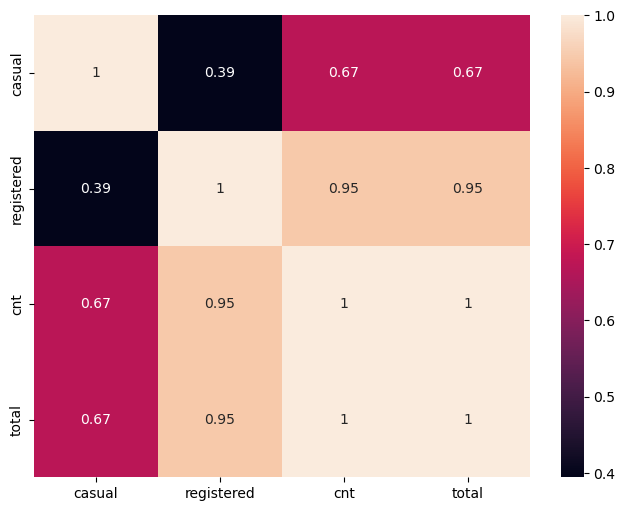

In [12]:
# Since cnt includes both casual and registered, we can check if there is any value difference
# Or if value total is more than casual + registered
df_count = df[['casual', 'registered', 'cnt']]

df_count['total'] = df_count['casual'] + df_count['registered']

plt.figure(figsize = (8,6))
sns.heatmap(df_count.corr(), annot = True)
plt.show()

In [13]:
# As we can see above, cnt = casual + registered without any extra values
# So we can safely remove casual and registered and take cnt as our dependent target variable
df.drop(['casual', 'registered'], axis = 1, inplace = True)
df.shape

(730, 12)

In [14]:
# Replacing numbers with values picked from data dictionary for categorical variables

df.mnth.replace({1: 'jan',2: 'feb',3: 'mar',4: 'apr',5: 'may',6: 'jun',
                  7: 'jul',8: 'aug',9: 'sept',10: 'oct',11: 'nov',12: 'dec'}, inplace = True)

df.season.replace({1:'spring', 2:'summer', 3:'fall', 4:'winter'},inplace = True)

df.weathersit.replace({1:'clear',2:'mist',3:'light_snow',4:'heavy_rain'},inplace = True)

df.weekday.replace({0: 'sun',1: 'mon',2: 'tue',3: 'wed',4: 'thu',5: 'fri',6: 'sat'},inplace = True)

df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,spring,0,jan,0,sat,0,mist,14.110847,18.18125,80.5833,10.749882,985
1,spring,0,jan,0,sun,0,mist,14.902598,17.68695,69.6087,16.652113,801
2,spring,0,jan,0,mon,1,clear,8.050924,9.47025,43.7273,16.636703,1349
3,spring,0,jan,0,tue,1,clear,8.200000,10.60610,59.0435,10.739832,1562
4,spring,0,jan,0,wed,1,clear,9.305237,11.46350,43.6957,12.522300,1600


count      730
unique       4
top       fall
freq       188
Name: season, dtype: object
['spring' 'summer' 'fall' 'winter']


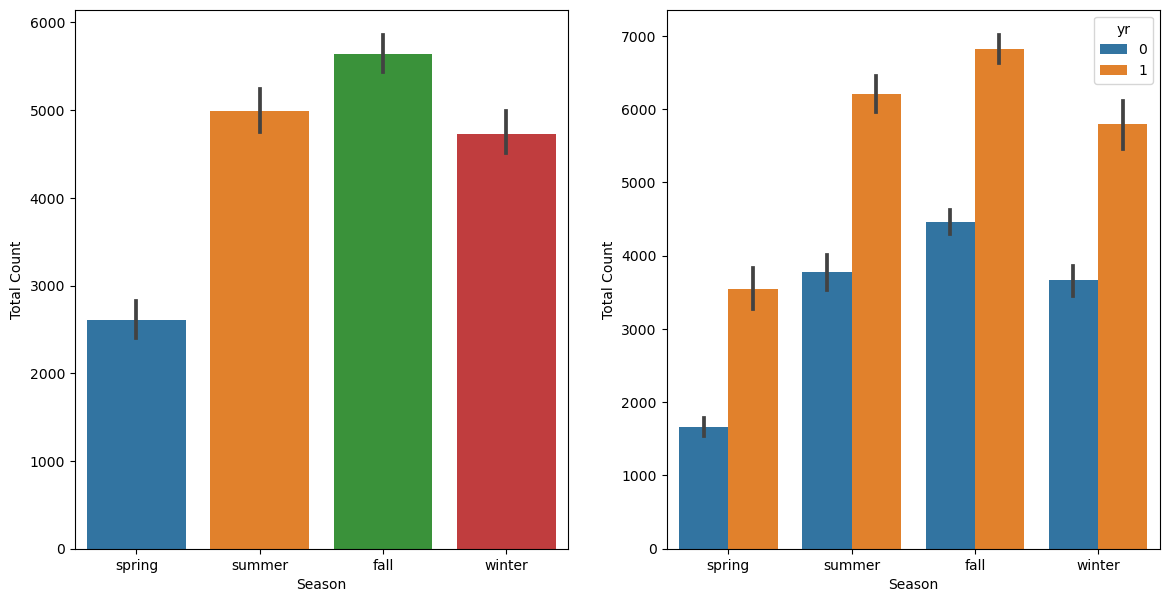

In [15]:
# Analysis of categorical variable - Season
# In general, maximum bookings happened in fall season
# More booking demands in 2019

print(df['season'].describe())
print(df['season'].unique())

plt.figure(figsize = (14,7))
plt.subplot(1,2,1)
ax = sns.barplot(x="season", y="cnt", data=df)
ax.set_xlabel('Season')
ax.set_ylabel('Total Count')
plt.subplot(1,2,2)
ax = sns.barplot(x="season", y="cnt",data=df, hue='yr')
ax.set_xlabel('Season')
ax.set_ylabel('Total Count')
plt.show()

count     730
unique     12
top       jan
freq       62
Name: mnth, dtype: object
['jan' 'feb' 'mar' 'apr' 'may' 'jun' 'jul' 'aug' 'sept' 'oct' 'nov' 'dec']


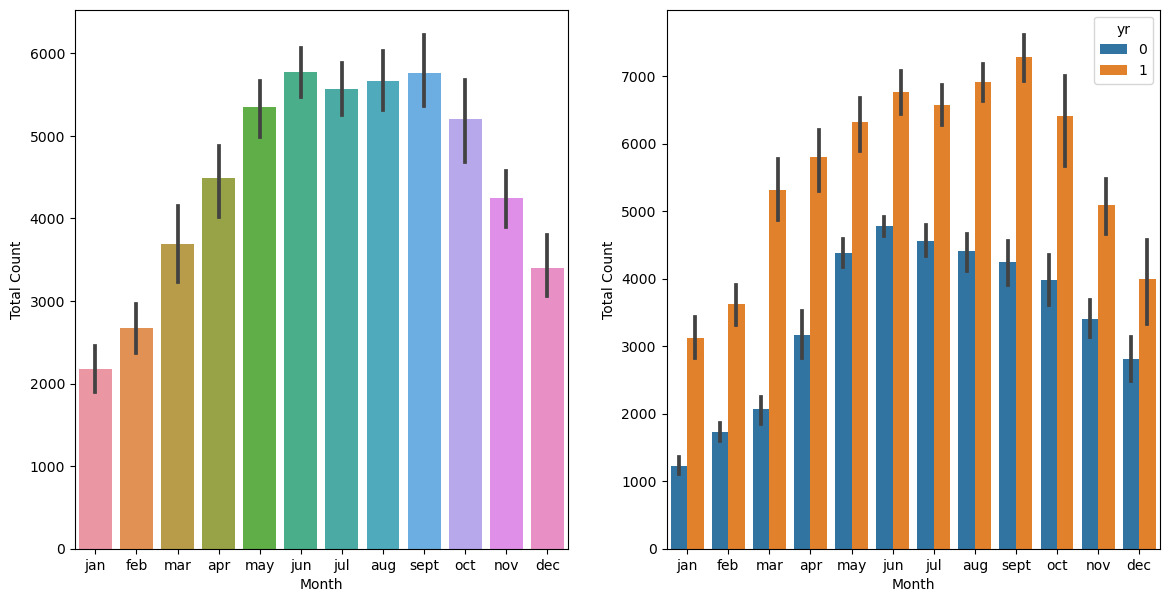

In [16]:
# Analysis of categorical variable - Month
# Roughly follows bell curve
# Bookings keep increasing, peak around may-sept, then start decreasing
# More booking demands in 2019

print(df['mnth'].describe())
print(df['mnth'].unique())

plt.figure(figsize = (14,7))
plt.subplot(1,2,1)
ax = sns.barplot(x="mnth", y="cnt", data=df)
ax.set_xlabel('Month')
ax.set_ylabel('Total Count')
plt.subplot(1,2,2)
ax = sns.barplot(x="mnth", y="cnt",data=df, hue='yr')
ax.set_xlabel('Month')
ax.set_ylabel('Total Count')
plt.show()

count     730
unique      7
top       sat
freq      105
Name: weekday, dtype: object
['sat' 'sun' 'mon' 'tue' 'wed' 'thu' 'fri']


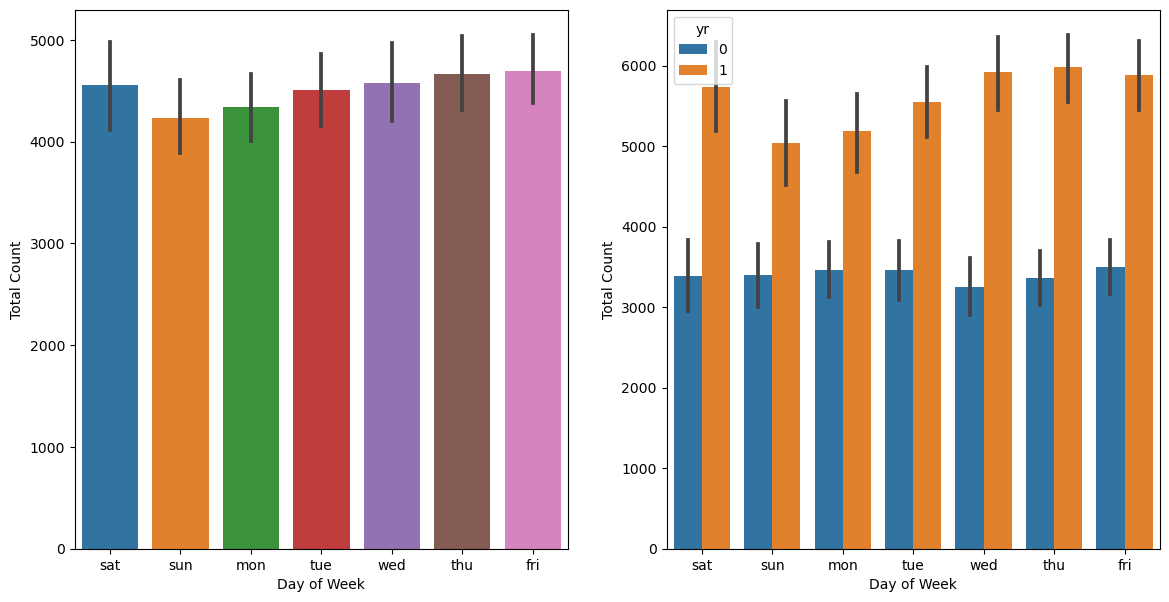

In [17]:
# Analysis of categorical variable - Weekday
# In general, maximum bookings happened on saturday; similar number for other days
# More booking demands in 2019

print(df['weekday'].describe())
print(df['weekday'].unique())

plt.figure(figsize = (14,7))
plt.subplot(1,2,1)
ax = sns.barplot(x="weekday", y="cnt", data=df)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Count')
plt.subplot(1,2,2)
ax = sns.barplot(x="weekday", y="cnt",data=df, hue='yr')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Count')
plt.show()

count    730.000000
mean       0.028767
std        0.167266
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Name: holiday, dtype: float64
[0 1]


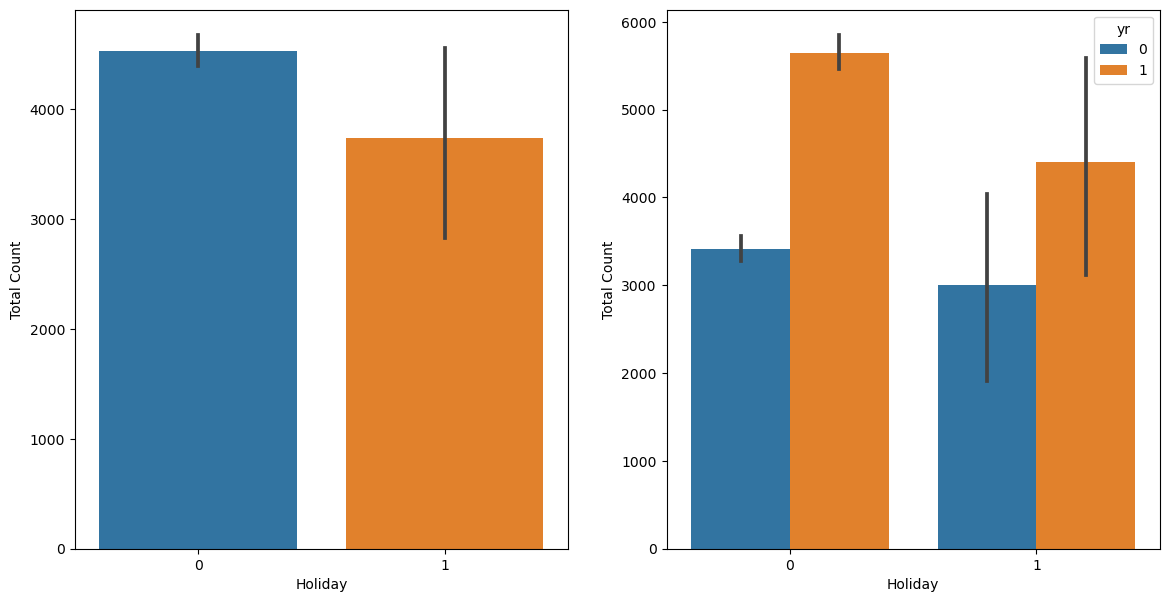

In [18]:
# Analysis of categorical variable - Holiday
# In general, demand seems decreased on holidays
# More booking demands in 2019

print(df['holiday'].describe())
print(df['holiday'].unique())

plt.figure(figsize = (14,7))
plt.subplot(1,2,1)
ax = sns.barplot(x="holiday", y="cnt", data=df)
ax.set_xlabel('Holiday')
ax.set_ylabel('Total Count')
plt.subplot(1,2,2)
ax = sns.barplot(x="holiday", y="cnt",data=df, hue='yr')
ax.set_xlabel('Holiday')
ax.set_ylabel('Total Count')
plt.show()

count    730.000000
mean       0.683562
std        0.465405
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: workingday, dtype: float64
[0 1]


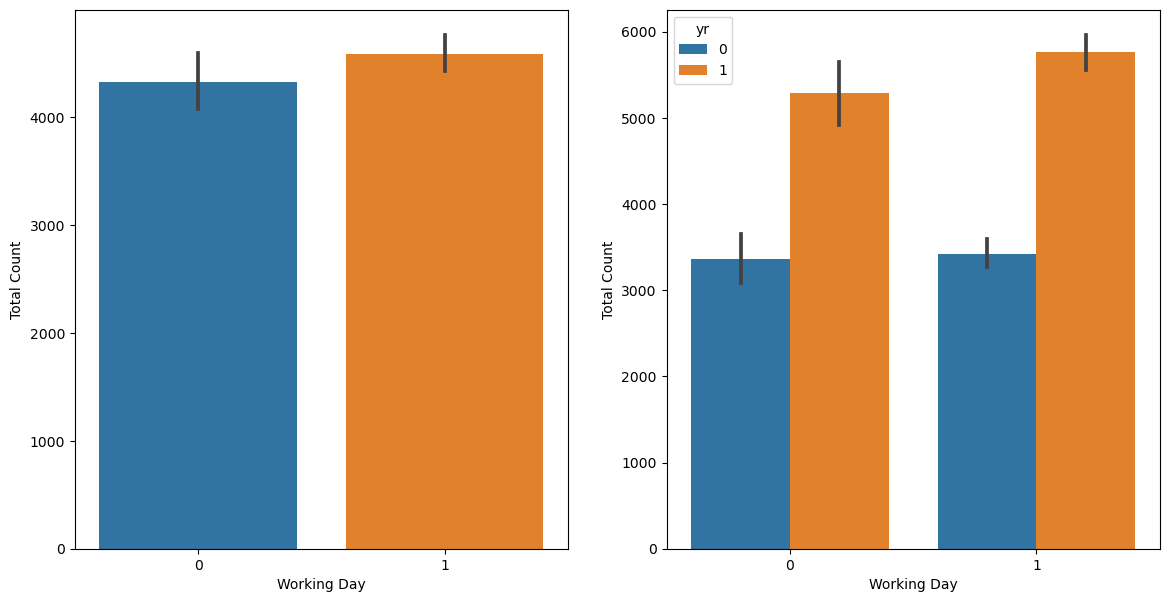

In [19]:
# Analysis of categorical variable - Working day
# In general, demand seems decreased on holidays and increased on working days
# More booking demands in 2019

print(df['workingday'].describe())
print(df['workingday'].unique())

plt.figure(figsize = (14,7))
plt.subplot(1,2,1)
ax = sns.barplot(x="workingday", y="cnt", data=df)
ax.set_xlabel('Working Day')
ax.set_ylabel('Total Count')
plt.subplot(1,2,2)
ax = sns.barplot(x="workingday", y="cnt",data=df, hue='yr')
ax.set_xlabel('Working Day')
ax.set_ylabel('Total Count')
plt.show()

count       730
unique        3
top       clear
freq        463
Name: weathersit, dtype: object
['mist' 'clear' 'light_snow']


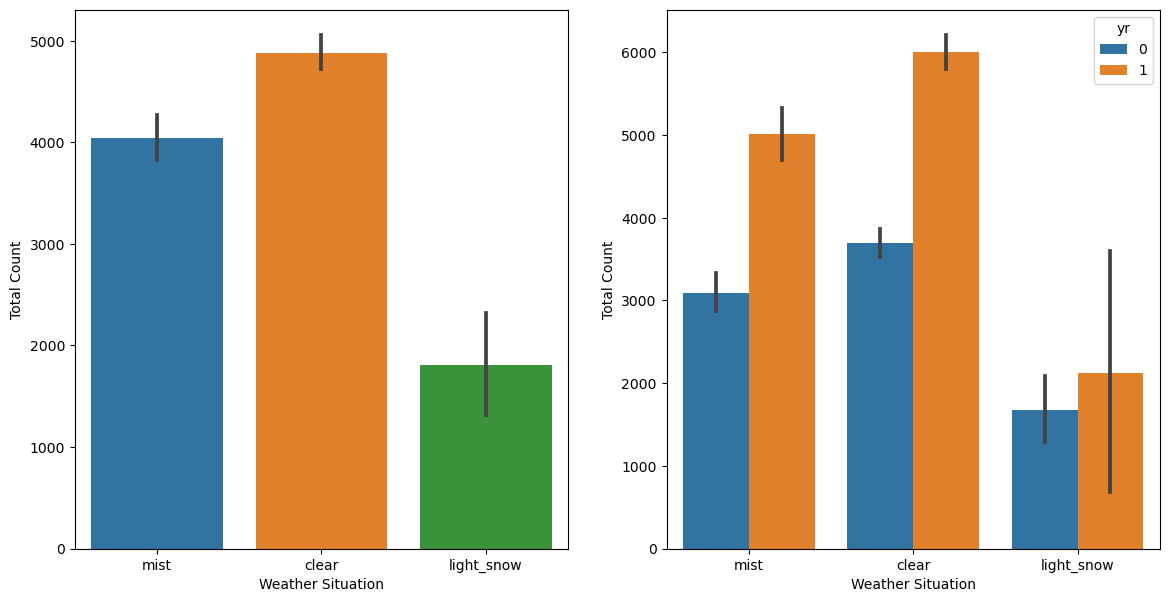

In [20]:
# Analysis of categorical variable - Weather Situation
# No bookings during heavy rain and snow
# In general, maximum demand on clear weather days
# More booking demands in 2019

print(df['weathersit'].describe())
print(df['weathersit'].unique())

plt.figure(figsize = (14,7))
plt.subplot(1,2,1)
ax = sns.barplot(x="weathersit", y="cnt", data=df)
ax.set_xlabel('Weather Situation')
ax.set_ylabel('Total Count')
plt.subplot(1,2,2)
ax = sns.barplot(x="weathersit", y="cnt",data=df, hue='yr')
ax.set_xlabel('Weather Situation')
ax.set_ylabel('Total Count')
plt.show()

count    730.000000
mean       0.500000
std        0.500343
min        0.000000
25%        0.000000
50%        0.500000
75%        1.000000
max        1.000000
Name: yr, dtype: float64
[0 1]


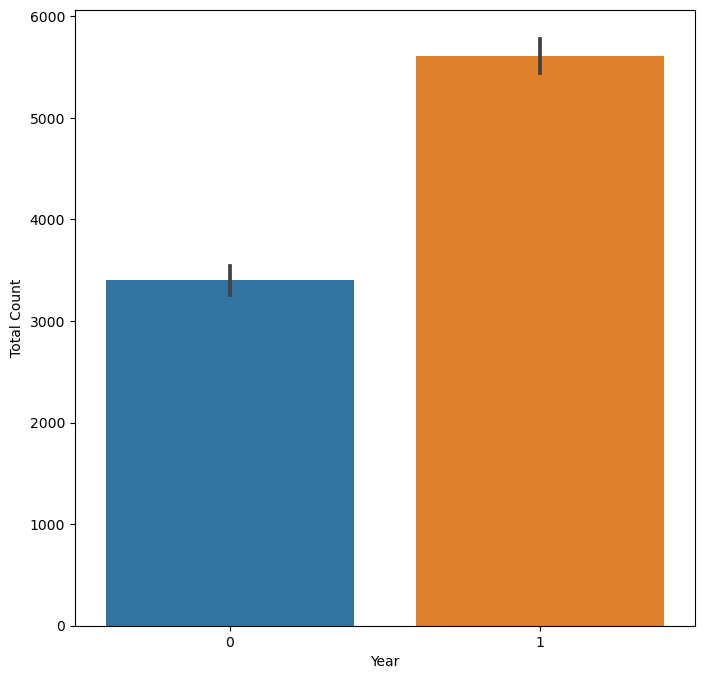

In [21]:
# Analysis of categorical variable - Year
# More booking demands in 2019; business progressing year over year

print(df['yr'].describe())
print(df['yr'].unique())

plt.figure(figsize = (8,8))
ax = sns.barplot(x="yr", y="cnt", data=df)
ax.set_xlabel('Year')
ax.set_ylabel('Total Count')
plt.show()

<Axes: ylabel='windspeed'>

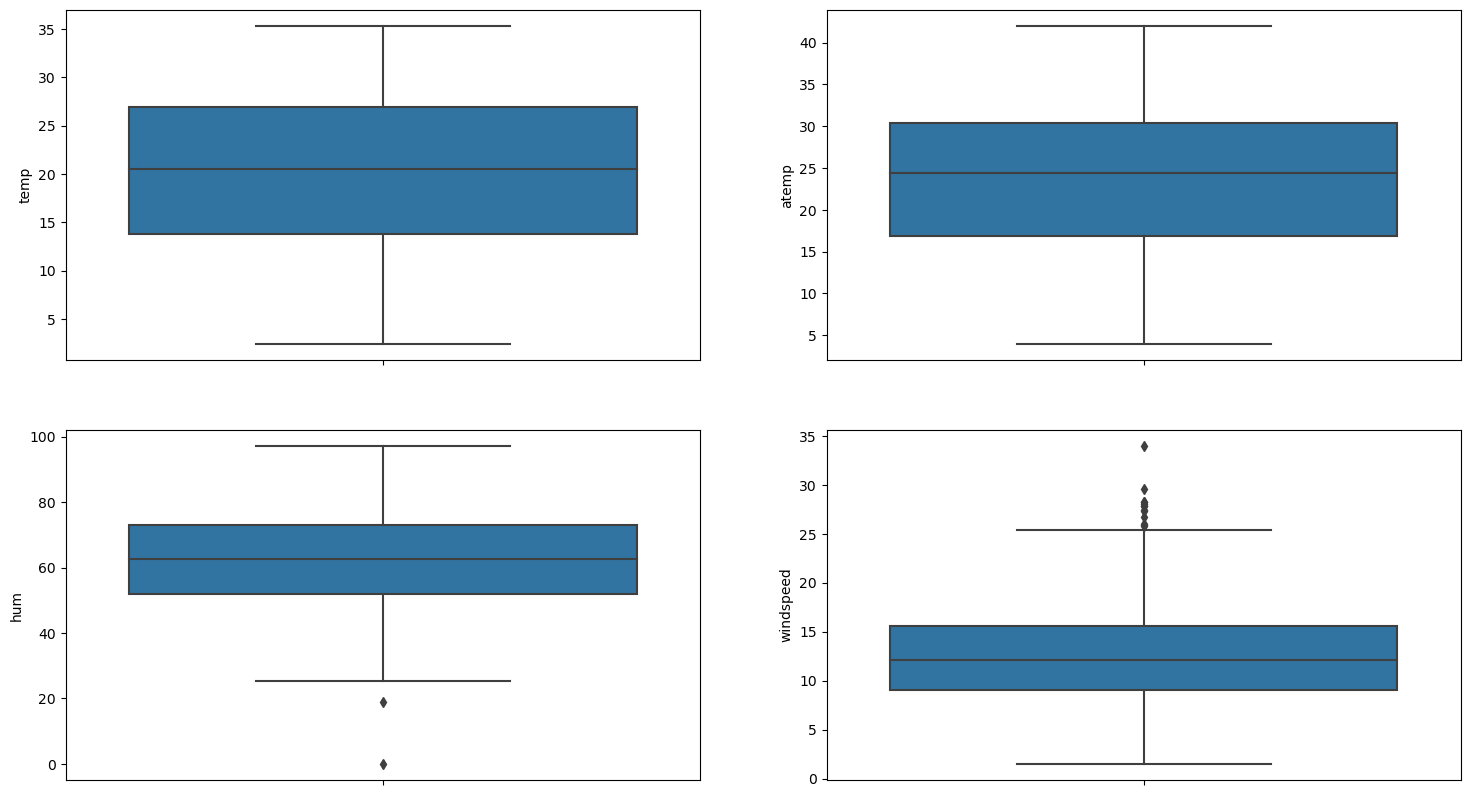

In [22]:
# Analyzing numeric variables and checking for outliers
# Doesn't seem to have extreme outliers
plt.figure(figsize=(18,10))
plt.subplot(2,2,1)
sns.boxplot(y='temp', data=df)
plt.subplot(2,2,2)
sns.boxplot(y='atemp', data=df)
plt.subplot(2,2,3)
sns.boxplot(y='hum', data=df)
plt.subplot(2,2,4)
sns.boxplot(y='windspeed', data=df)

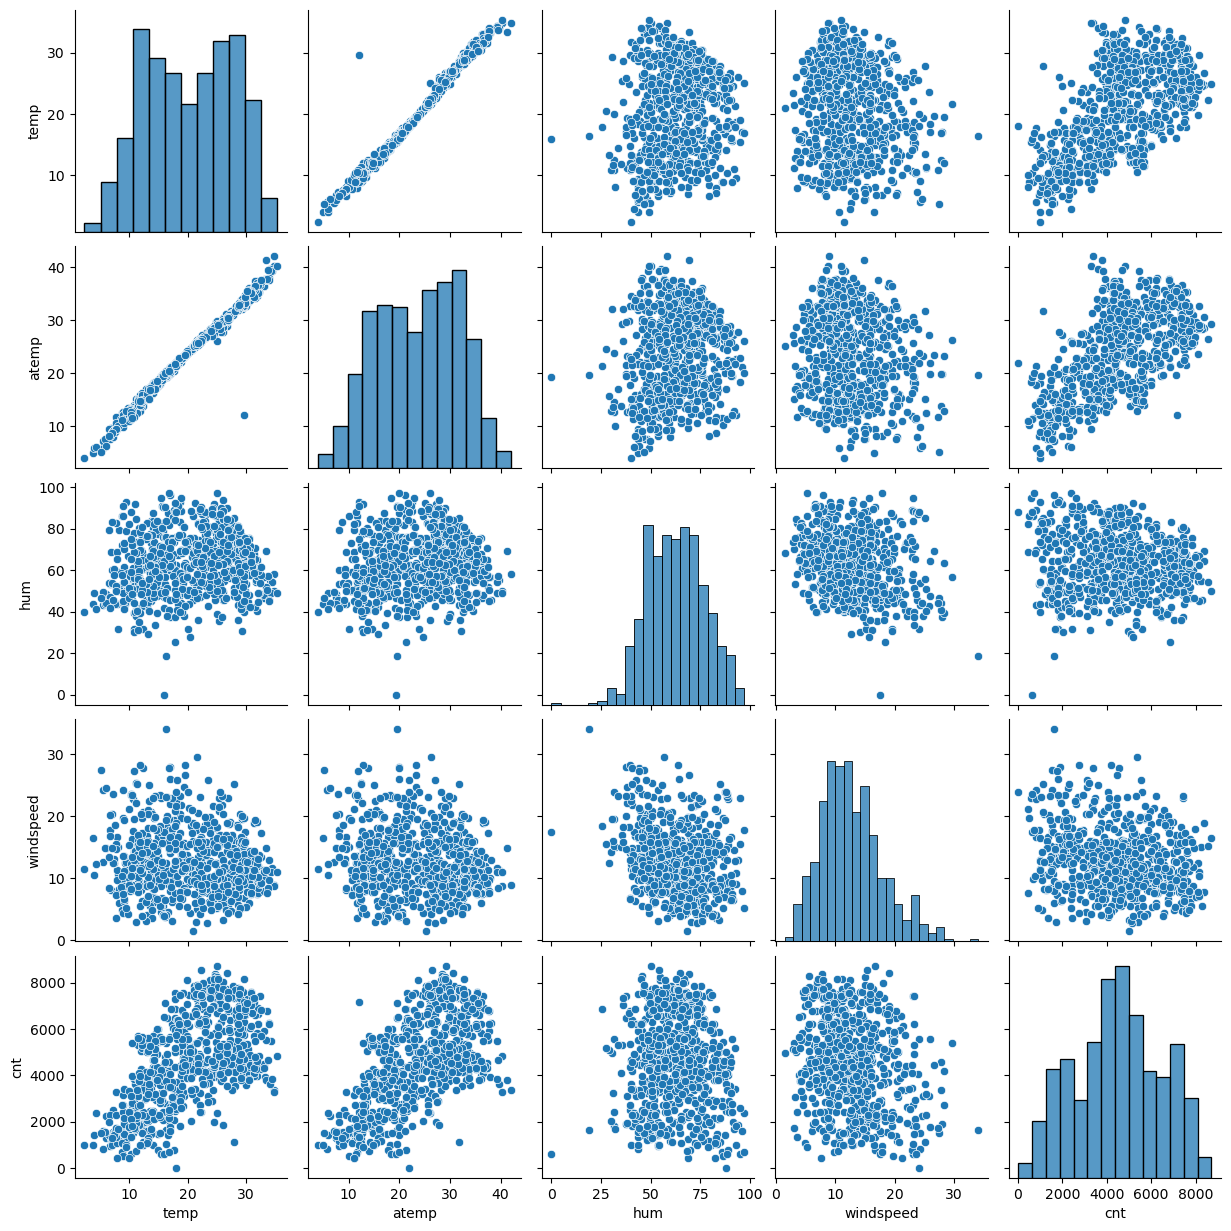

In [23]:
# Pair plot of numeric variables
# atemp and temp seem to have linear relation; we'll mostly end up dropping one of those
sns.pairplot(data=df,vars=['temp','atemp','hum','windspeed','cnt'])
plt.show()

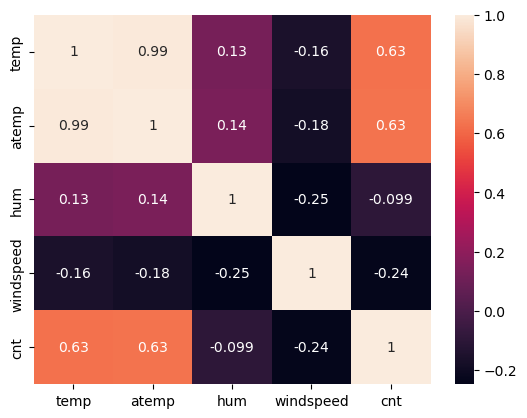

In [24]:
# Numeric variables correlation matrix
sns.heatmap(df[['temp','atemp','hum','windspeed','cnt']].corr(), annot = True)
plt.show()

## Prepare dataset for model building and split into train and test

In [25]:
# Create dummy variables for categorical values
df = pd.get_dummies(data=df,columns=["season","mnth","weekday", "weathersit"],drop_first=True,dtype=int)

In [26]:
# n-1 columns added for n possible categorical values in a variable
print(df.shape)
print(df.columns)

(730, 30)
Index(['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed',
       'cnt', 'season_spring', 'season_summer', 'season_winter', 'mnth_aug',
       'mnth_dec', 'mnth_feb', 'mnth_jan', 'mnth_jul', 'mnth_jun', 'mnth_mar',
       'mnth_may', 'mnth_nov', 'mnth_oct', 'mnth_sept', 'weekday_mon',
       'weekday_sat', 'weekday_sun', 'weekday_thu', 'weekday_tue',
       'weekday_wed', 'weathersit_light_snow', 'weathersit_mist'],
      dtype='object')


In [27]:
df.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_spring,season_summer,...,mnth_oct,mnth_sept,weekday_mon,weekday_sat,weekday_sun,weekday_thu,weekday_tue,weekday_wed,weathersit_light_snow,weathersit_mist
0,0,0,0,14.110847,18.18125,80.5833,10.749882,985,1,0,...,0,0,0,1,0,0,0,0,0,1
1,0,0,0,14.902598,17.68695,69.6087,16.652113,801,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,0,1,8.050924,9.47025,43.7273,16.636703,1349,1,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,1,8.200000,10.60610,59.0435,10.739832,1562,1,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,1,9.305237,11.46350,43.6957,12.522300,1600,1,0,...,0,0,0,0,0,0,0,1,0,0


In [28]:
# Splitting data; training data is 70%; testing data is 30%
np.random.seed(0)
df_train, df_test = train_test_split(df, train_size = 0.7, random_state = 100)

In [29]:
df_train.shape

(510, 30)

In [30]:
df_test.shape

(220, 30)

In [31]:
# Rescale variables so that all numeric variables have a comparable scale of values
scaler = MinMaxScaler()

# Apply scaler to all the columns except the dummy variables
num_vars = ['temp', 'atemp', 'hum', 'windspeed','cnt']

df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

In [32]:
df_train.shape

(510, 30)

In [33]:
df_train.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_spring,season_summer,...,mnth_oct,mnth_sept,weekday_mon,weekday_sat,weekday_sun,weekday_thu,weekday_tue,weekday_wed,weathersit_light_snow,weathersit_mist
576,1,0,1,0.815169,0.766351,0.725633,0.264686,0.827658,0,0,...,0,0,0,0,0,0,1,0,0,0
426,1,0,0,0.442393,0.438975,0.640189,0.255342,0.465255,1,0,...,0,0,0,1,0,0,0,0,0,1
728,1,0,0,0.245101,0.200348,0.498067,0.663106,0.204096,1,0,...,0,0,0,0,1,0,0,0,0,0
482,1,0,0,0.395666,0.391735,0.504508,0.188475,0.482973,0,1,...,0,0,0,1,0,0,0,0,0,1
111,0,0,1,0.345824,0.318819,0.751824,0.380981,0.191095,0,1,...,0,0,0,0,0,0,0,0,0,1


In [34]:
# Since we need to predict count of bikes rented; cnt is separated as dependent variable
# Remaining all columns are separated as independent variables

y_train = df_train.pop('cnt')
X_train = df_train

## Model Building and Evaluation

In [35]:
# Running RFE with the output number of the variable equal to 20 (out of 29)
lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(lm, step=20)
rfe = rfe.fit(X_train, y_train)

In [36]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('yr', True, 1),
 ('holiday', True, 1),
 ('workingday', True, 1),
 ('temp', True, 1),
 ('atemp', False, 2),
 ('hum', True, 1),
 ('windspeed', True, 1),
 ('season_spring', True, 1),
 ('season_summer', False, 2),
 ('season_winter', True, 1),
 ('mnth_aug', False, 2),
 ('mnth_dec', False, 2),
 ('mnth_feb', False, 2),
 ('mnth_jan', True, 1),
 ('mnth_jul', True, 1),
 ('mnth_jun', False, 2),
 ('mnth_mar', False, 2),
 ('mnth_may', False, 2),
 ('mnth_nov', False, 2),
 ('mnth_oct', False, 2),
 ('mnth_sept', True, 1),
 ('weekday_mon', False, 2),
 ('weekday_sat', True, 1),
 ('weekday_sun', True, 1),
 ('weekday_thu', False, 2),
 ('weekday_tue', False, 2),
 ('weekday_wed', False, 2),
 ('weathersit_light_snow', True, 1),
 ('weathersit_mist', False, 2)]

In [37]:
col = X_train.columns[rfe.support_]
col

Index(['yr', 'holiday', 'workingday', 'temp', 'hum', 'windspeed',
       'season_spring', 'season_winter', 'mnth_jan', 'mnth_jul', 'mnth_sept',
       'weekday_sat', 'weekday_sun', 'weathersit_light_snow'],
      dtype='object')

In [38]:
# Since 14 columns have rank 1 and the rest rank 2; it picks up 14 columns even if defined step was 20
col.shape

(14,)

In [39]:
# Left out columns
X_train.columns[~rfe.support_]

Index(['atemp', 'season_summer', 'mnth_aug', 'mnth_dec', 'mnth_feb',
       'mnth_jun', 'mnth_mar', 'mnth_may', 'mnth_nov', 'mnth_oct',
       'weekday_mon', 'weekday_thu', 'weekday_tue', 'weekday_wed',
       'weathersit_mist'],
      dtype='object')

In [40]:
# Based on our EDA plots, let's add any remaining visible impact variables to the RFE selected subset
col1 = ['yr', 'holiday', 'workingday', 'temp', 'hum', 'windspeed',
       'season_spring', 'season_winter', 'mnth_jan', 'mnth_sept',
       'weekday_sat', 'weekday_sun', 'weathersit_light_snow',
       'weathersit_mist', 'season_summer', 'mnth_nov']

In [41]:
# Creating X_test dataframe with RFE selected variables
X_train_rfe = X_train[col1]

# Adding a constant variable   
X_train_rfe_sm = sm.add_constant(X_train_rfe)

lm = sm.OLS(y_train,X_train_rfe_sm).fit()

print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     181.1
Date:                Wed, 10 Apr 2024   Prob (F-statistic):          1.22e-189
Time:                        12:18:00   Log-Likelihood:                 516.16
No. Observations:                 510   AIC:                            -1000.
Df Residuals:                     494   BIC:                            -932.6
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.20

In [42]:
# Generic function to calculate VIF of variables

def calculateVIF(df):
    vif = pd.DataFrame()
    vif['Features'] = df.columns
    vif['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    return vif 

In [43]:
# Generic function to re-build the model after removing variables

def runOLS(X_train_val):
    X_train_val_sm = sm.add_constant(X_train_val)
    lm_val = sm.OLS(y_train,X_train_val_sm).fit()
    print(lm_val.summary())
    return lm_val,X_train_val_sm

In [44]:
# Calculate the VIFs for the new model
calculateVIF(X_train_rfe)

,Features,VIF
2,workingday,52.77
10,weekday_sat,12.64
11,weekday_sun,12.16
6,season_spring,5.00
3,temp,3.87
7,season_winter,3.57
1,holiday,3.06
14,season_summer,2.35
4,hum,1.91
8,mnth_jan,1.57


In [45]:
# Since holiday has high p-value (0.582 > 0.05) and low VIF, we'll drop it
X_train_new = X_train_rfe.drop(['holiday'], axis=1)

In [46]:
# Re-build model after dropping holiday   
runOLS(X_train_new)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     181.1
Date:                Wed, 10 Apr 2024   Prob (F-statistic):          1.22e-189
Time:                        12:18:33   Log-Likelihood:                 516.16
No. Observations:                 510   AIC:                            -1000.
Df Residuals:                     494   BIC:                            -932.6
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.19

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x16a443e10>,
      const  yr  workingday      temp       hum  windspeed  season_spring  \
 576    1.0   1           1  0.815169  0.725633   0.264686              0   
 426    1.0   1           0  0.442393  0.640189   0.255342              1   
 728    1.0   1           0  0.245101  0.498067   0.663106              1   
 482    1.0   1           0  0.395666  0.504508   0.188475              0   
 111    1.0   0           1  0.345824  0.751824   0.380981              0   
 ..     ...  ..         ...       ...       ...        ...            ...   
 578    1.0   1           1  0.863973  0.679690   0.187140              0   
 53     1.0   0           1  0.202618  0.435939   0.111379              1   
 350    1.0   0           0  0.248216  0.577930   0.431816              0   
 79     1.0   0           1  0.462664  0.759870   0.529881              0   
 520    1.0   1           1  0.600225  0.632030   0.359599              0

In [47]:
calculateVIF(X_train_new)

,Features,VIF
3,hum,32.83
2,temp,19.00
1,workingday,18.48
4,windspeed,4.99
9,weekday_sat,4.92
5,season_spring,4.90
10,weekday_sun,4.76
6,season_winter,3.99
13,season_summer,2.69
12,weathersit_mist,2.32


In [48]:
# next, month_nov has high p-value (0.185 > 0.05) and low VIF so dropping it
X_train_new_2 = X_train_new.drop(['mnth_nov'], axis=1)

In [49]:
calculateVIF(X_train_new_2)

,Features,VIF
3,hum,32.74
2,temp,18.93
1,workingday,18.47
4,windspeed,4.92
9,weekday_sat,4.92
5,season_spring,4.88
10,weekday_sun,4.75
6,season_winter,3.56
13,season_summer,2.68
12,weathersit_mist,2.31


In [50]:
runOLS(X_train_new_2)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     193.6
Date:                Wed, 10 Apr 2024   Prob (F-statistic):          2.06e-190
Time:                        12:18:51   Log-Likelihood:                 515.25
No. Observations:                 510   AIC:                            -1000.
Df Residuals:                     495   BIC:                            -937.0
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.18

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x16a4554d0>,
      const  yr  workingday      temp       hum  windspeed  season_spring  \
 576    1.0   1           1  0.815169  0.725633   0.264686              0   
 426    1.0   1           0  0.442393  0.640189   0.255342              1   
 728    1.0   1           0  0.245101  0.498067   0.663106              1   
 482    1.0   1           0  0.395666  0.504508   0.188475              0   
 111    1.0   0           1  0.345824  0.751824   0.380981              0   
 ..     ...  ..         ...       ...       ...        ...            ...   
 578    1.0   1           1  0.863973  0.679690   0.187140              0   
 53     1.0   0           1  0.202618  0.435939   0.111379              1   
 350    1.0   0           0  0.248216  0.577930   0.431816              0   
 79     1.0   0           1  0.462664  0.759870   0.529881              0   
 520    1.0   1           1  0.600225  0.632030   0.359599              0

In [51]:
# Next, season_spring has high p-value (0.056 > 0.05) and low VIF, so we'll drop it
X_train_new_3 = X_train_new_2.drop(['season_spring'], axis=1)

In [52]:
runOLS(X_train_new_3)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     207.1
Date:                Wed, 10 Apr 2024   Prob (F-statistic):          8.66e-191
Time:                        12:18:53   Log-Likelihood:                 513.37
No. Observations:                 510   AIC:                            -998.7
Df Residuals:                     496   BIC:                            -939.5
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.14

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x16a3358d0>,
      const  yr  workingday      temp       hum  windspeed  season_winter  \
 576    1.0   1           1  0.815169  0.725633   0.264686              0   
 426    1.0   1           0  0.442393  0.640189   0.255342              0   
 728    1.0   1           0  0.245101  0.498067   0.663106              0   
 482    1.0   1           0  0.395666  0.504508   0.188475              0   
 111    1.0   0           1  0.345824  0.751824   0.380981              0   
 ..     ...  ..         ...       ...       ...        ...            ...   
 578    1.0   1           1  0.863973  0.679690   0.187140              0   
 53     1.0   0           1  0.202618  0.435939   0.111379              0   
 350    1.0   0           0  0.248216  0.577930   0.431816              1   
 79     1.0   0           1  0.462664  0.759870   0.529881              0   
 520    1.0   1           1  0.600225  0.632030   0.359599              0

In [53]:
calculateVIF(X_train_new_3)

,Features,VIF
3,hum,27.02
1,workingday,16.01
2,temp,10.83
8,weekday_sat,4.35
4,windspeed,4.33
9,weekday_sun,4.25
11,weathersit_mist,2.21
0,yr,2.07
5,season_winter,1.95
12,season_summer,1.70


In [54]:
# Now all remaining variables have low p-value
# So we move onto removing ones with high VIF, starting with humidity
X_train_new_4 = X_train_new_3.drop(['hum'], axis=1)

In [55]:
runOLS(X_train_new_4)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     215.6
Date:                Wed, 10 Apr 2024   Prob (F-statistic):          3.49e-188
Time:                        12:18:55   Log-Likelihood:                 504.38
No. Observations:                 510   AIC:                            -982.8
Df Residuals:                     497   BIC:                            -927.7
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.05

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x16a327150>,
      const  yr  workingday      temp  windspeed  season_winter  mnth_jan  \
 576    1.0   1           1  0.815169   0.264686              0         0   
 426    1.0   1           0  0.442393   0.255342              0         0   
 728    1.0   1           0  0.245101   0.663106              0         0   
 482    1.0   1           0  0.395666   0.188475              0         0   
 111    1.0   0           1  0.345824   0.380981              0         0   
 ..     ...  ..         ...       ...        ...            ...       ...   
 578    1.0   1           1  0.863973   0.187140              0         0   
 53     1.0   0           1  0.202618   0.111379              0         0   
 350    1.0   0           0  0.248216   0.431816              1         0   
 79     1.0   0           1  0.462664   0.529881              0         0   
 520    1.0   1           1  0.600225   0.359599              0         0

In [56]:
calculateVIF(X_train_new_4)

,Features,VIF
1,workingday,10.87
2,temp,8.48
3,windspeed,4.33
7,weekday_sat,3.25
8,weekday_sun,3.03
0,yr,2.06
4,season_winter,1.69
11,season_summer,1.68
10,weathersit_mist,1.59
5,mnth_jan,1.49


In [57]:
# workingday has highest VIF on re-calculation, so removing it
X_train_new_5 = X_train_new_4.drop(['workingday'], axis=1)

In [58]:
runOLS(X_train_new_5)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     227.0
Date:                Wed, 10 Apr 2024   Prob (F-statistic):          5.30e-186
Time:                        12:18:58   Log-Likelihood:                 496.38
No. Observations:                 510   AIC:                            -968.8
Df Residuals:                     498   BIC:                            -918.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.15

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x16a3f4b90>,
      const  yr      temp  windspeed  season_winter  mnth_jan  mnth_sept  \
 576    1.0   1  0.815169   0.264686              0         0          0   
 426    1.0   1  0.442393   0.255342              0         0          0   
 728    1.0   1  0.245101   0.663106              0         0          0   
 482    1.0   1  0.395666   0.188475              0         0          0   
 111    1.0   0  0.345824   0.380981              0         0          0   
 ..     ...  ..       ...        ...            ...       ...        ...   
 578    1.0   1  0.863973   0.187140              0         0          0   
 53     1.0   0  0.202618   0.111379              0         0          0   
 350    1.0   0  0.248216   0.431816              1         0          0   
 79     1.0   0  0.462664   0.529881              0         0          0   
 520    1.0   1  0.600225   0.359599              0         0          0   
 
      

In [59]:
calculateVIF(X_train_new_5)

,Features,VIF
1,temp,3.87
2,windspeed,3.37
0,yr,2.04
10,season_summer,1.62
9,weathersit_mist,1.53
3,season_winter,1.44
4,mnth_jan,1.22
6,weekday_sat,1.21
5,mnth_sept,1.20
7,weekday_sun,1.20


In [60]:
# Now, upon re-building and re-calculation, we have weekday_sat with high p-value (0.180 > 0.05)
X_train_new_6 = X_train_new_5.drop(['weekday_sat'], axis=1)

In [61]:
lm_6,X_train_new_6_sm = runOLS(X_train_new_6)

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     249.1
Date:                Wed, 10 Apr 2024   Prob (F-statistic):          8.04e-187
Time:                        12:19:01   Log-Likelihood:                 495.46
No. Observations:                 510   AIC:                            -968.9
Df Residuals:                     499   BIC:                            -922.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.15

In [62]:
# Finally, in model lm_6, the p-values are all < 0.05 and VIF values are all < 5
# So this becomes our final model
calculateVIF(X_train_new_6)

,Features,VIF
1,temp,3.83
2,windspeed,3.31
0,yr,2.04
9,season_summer,1.62
8,weathersit_mist,1.53
3,season_winter,1.43
4,mnth_jan,1.21
5,mnth_sept,1.20
6,weekday_sun,1.16
7,weathersit_light_snow,1.08


### Hence, temp, windspeed, yr, season_summer, weathersit_mist, season_winter, mnth_jan, mnth_sept, weekday_sun, weathersit_light_snow are the most significant predictor variables for determining count of bikes shared/rented

## Residual Analysis of training data and Testing Assumptions

In [63]:
# Count values predicted by the model on X_train

y_train_pred = lm_6.predict(X_train_new_6_sm)

### Error Terms are normally distributed

Text(0.5, 0, 'Errors')

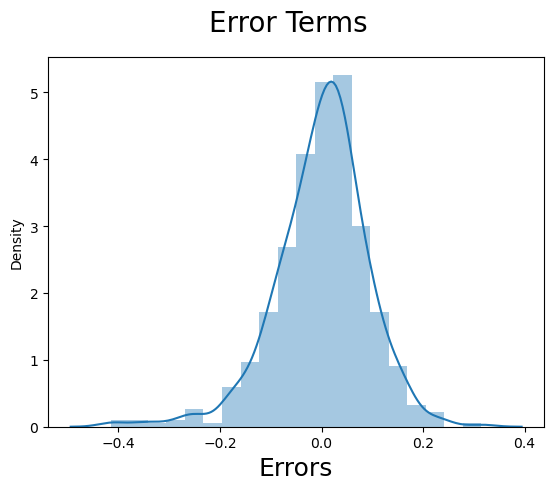

In [64]:
# Plot the histogram of the error terms
# Error terms = Actual training data - Predicted training data

fig = plt.figure()
sns.distplot((y_train - y_train_pred), bins = 20)
fig.suptitle('Error Terms', fontsize = 20) 
plt.xlabel('Errors', fontsize = 18)

### Error terms are independent of each other (low VIF = low multicollinearity)

In [65]:
calculateVIF(X_train_new_6)

,Features,VIF
1,temp,3.83
2,windspeed,3.31
0,yr,2.04
9,season_summer,1.62
8,weathersit_mist,1.53
3,season_winter,1.43
4,mnth_jan,1.21
5,mnth_sept,1.20
6,weekday_sun,1.16
7,weathersit_light_snow,1.08


### Error terms do not form patterns; constant variance (homoscedasticity)

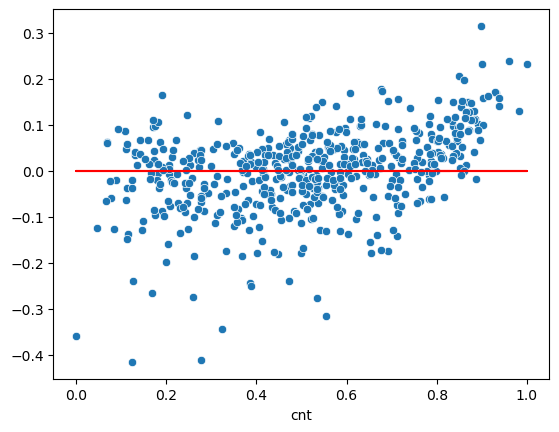

In [66]:
sns.scatterplot(x=y_train,y=(y_train - y_train_pred))
plt.plot(y_train,(y_train - y_train), '-r')
plt.show()

### p-value of almost all coefficients are zero; rejecting the null hypothesis that slope is significant

### P(F-statistic) is almost zero which implies that the fit is significant

In [67]:
lm_6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    cnt   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     249.1
Date:                Wed, 10 Apr 2024   Prob (F-statistic):          8.04e-187
Time:                        12:19:12   Log-Likelihood:                 495.46
No. Observations:                 510   AIC:                            -968.9
Df Residuals:                     499   BIC:                            -922.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.1558      0.020      7.908      0.000       0.117       0.195
yr                        0.2341      0.008     28.284      0.000       0.218       0.250
temp                      0.5216      0.023     22.649      0.000       0.476       0.567
windspeed                -0.1632      0.025     -6.432      0.000      -0.213      -0.113
season_winter             0.1178      0.011     10.359      0.000       0.095       0.140
mnth_jan                 -0.0469      0.018     -2.619      0.009      -0.082      -0.012
mnth_sept                 0.0936      0.016      5.897      0.000       0.062       0.125
weekday_sun              -0.0467      0.012     -3.971      0.000      -0.070      -0.024
weathersit_light_snow    -0.2851      0.025    -11.460      0.000      -0.334      -0.236
weathersit_mist          -0.0776      0.009     -8.812      0.000      -0.095      -0.060
season_summer             0.0819      0.011      7.626      0.000       0.061       0.103
==============================================================================
Omnibus:                       73.390   Durbin-Watson:                   2.052
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              174.375
Skew:                          -0.752   Prob(JB):                     1.36e-38
Kurtosis:                       5.438   Cond. No.                         11.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Making Predictions on Test Data

In [68]:
# Applying scaling on the test dataset

num_vars = ['temp', 'atemp', 'hum', 'windspeed','cnt']
df_test[num_vars] = scaler.transform(df_test[num_vars])
df_test.head()

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_spring,season_summer,...,mnth_oct,mnth_sept,weekday_mon,weekday_sat,weekday_sun,weekday_thu,weekday_tue,weekday_wed,weathersit_light_snow,weathersit_mist
184,0,1,0,0.831783,0.769660,0.657364,0.084219,0.692706,0,0,...,0,0,1,0,0,0,0,0,0,1
535,1,0,1,0.901354,0.842587,0.610133,0.153728,0.712034,0,1,...,0,0,0,0,0,0,0,1,0,0
299,0,0,1,0.511964,0.496145,0.837699,0.334206,0.303382,0,0,...,1,0,0,0,0,1,0,0,0,1
221,0,0,1,0.881625,0.795343,0.437098,0.339570,0.547400,0,0,...,0,0,0,0,0,0,0,1,0,0
152,0,0,1,0.817246,0.741471,0.314298,0.537414,0.569029,0,1,...,0,0,0,0,0,1,0,0,0,0


In [69]:
y_test = df_test.pop('cnt')
X_test = df_test

In [70]:
col1 = X_train_new_6.columns
X_test = X_test[col1]

X_test_lm_6 = sm.add_constant(X_test)

In [71]:
y_pred = lm_6.predict(X_test_lm_6)

Text(0, 0.5, 'y_pred')

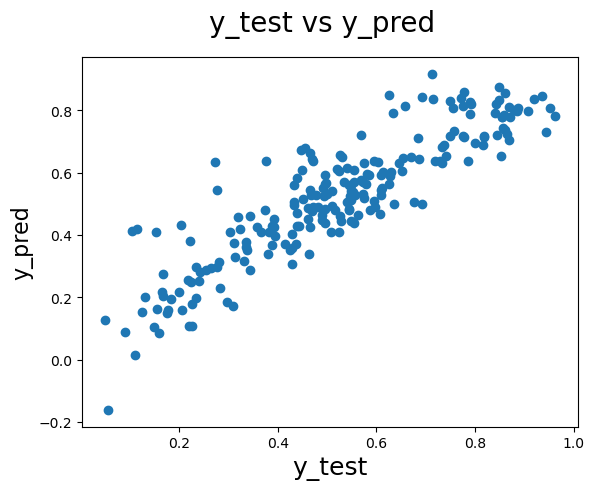

In [72]:
# Plotting y_test and y_pred to understand the spread

fig = plt.figure()
plt.scatter(y_test, y_pred)
fig.suptitle('y_test vs y_pred', fontsize = 20) 
plt.xlabel('y_test', fontsize = 18)
plt.ylabel('y_pred', fontsize = 16) 

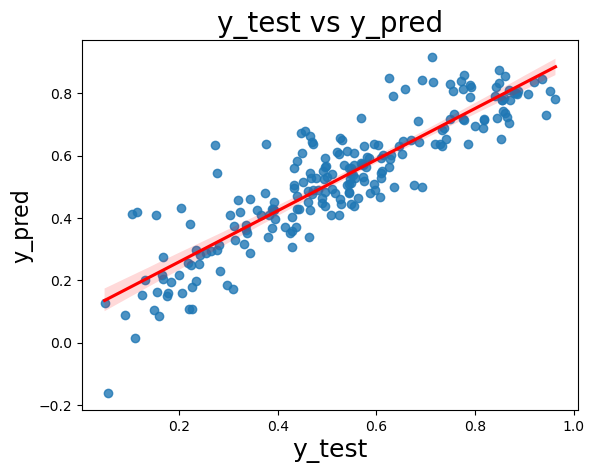

In [80]:
# Visualizing the fit on the test data

plt.figure()
sns.regplot(x=y_test, y=y_pred, fit_reg=True, line_kws={"color": "red"})
plt.title('y_test vs y_pred', fontsize=20)
plt.xlabel('y_test', fontsize=18)
plt.ylabel('y_pred', fontsize=16)
plt.show()

In [81]:
r2 = r2_score(y_test, y_pred)
r2

0.7903539377827853

In [82]:
adjusted_r2 = 1-(1-r2)*(X_test.shape[0]-1)/(X_test.shape[0]-X_test.shape[1]-1)
print(adjusted_r2)

0.780323025714976


### Train data 

r2_score = 0.83
<br>
adjusted_r2_score = 0.83

### Test data 

r2_score = 0.79
<br>
adjusted_r2_score = 0.78

In [83]:
pd.options.display.float_format = '{:.3f}'.format 
lm_6.params

const                    0.156
yr                       0.234
temp                     0.522
windspeed               -0.163
season_winter            0.118
mnth_jan                -0.047
mnth_sept                0.094
weekday_sun             -0.047
weathersit_light_snow   -0.285
weathersit_mist         -0.078
season_summer            0.082
dtype: float64

### We can see that the equation of our best fitted line is:

$ cnt = 0.156 + 0.234  \times  yr + 0.522  \times  temp - 0.163 \times windspeed + 0.118 \times season_winter - 0.047 \times mnth_jan + 0.094 \times mnth_sept - 0.047 \times weekday_sun - 0.285 \times weathersit_light_snow - 0.078 \times weathersit_mist + 0.082 \times season_summer $